### News categorization using tf-idf and naive bayes


In [3]:

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC 
# linear svc is used because it is fast and performs well on tf-idf features. 

In [4]:
df = pd.read_csv("../datasets/bbc_news_dataset.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.0+ KB


In [6]:
df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [7]:
X = df['Text']
y = df['Category']

In [8]:
category_names = y.unique()
category_names

array(['business', 'tech', 'politics', 'sport', 'entertainment'],
      dtype=object)

In [9]:
value_counts = df['Category'].value_counts()
value_counts

Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64

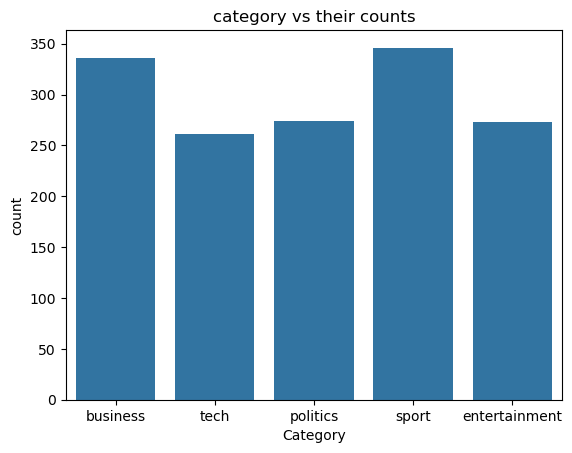

In [10]:
sns.countplot(x='Category',data=df)
plt.title("category vs their counts")
plt.show()

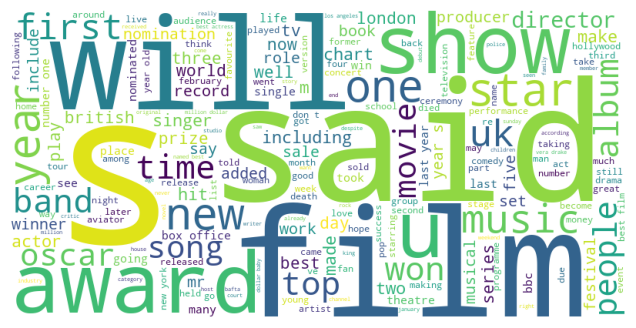

In [11]:
# generating word clouds 

from wordcloud import WordCloud

for category in category_names:
    text = " ".join(df[df['Category'] ==  category]['Text'].values)
    wc = WordCloud(width=800,height=400,background_color='white').generate(text)
plt.figure(figsize=(8,4))
plt.imshow(wc)
plt.axis('off')
plt.show()

In [12]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
X_train

1166    fuming robinson blasts officials england coach...
1106    huge rush for jet airways shares indian airlin...
538     voters  don t trust politicians  eight out of ...
439     dundee utd 4-1 aberdeen dundee united eased in...
1478    visa row mandarin made sir john the top civil ...
                              ...                        
1130    blair  said he would stand down  tony blair pr...
1294    us trade gap hits record in 2004 the gap betwe...
860     tories pledge free sports lessons children wou...
1459    dance music not dead says fatboy dj norman coo...
1126    greek pair attend drugs hearing greek sprinter...
Name: Text, Length: 1192, dtype: object

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    TfidfVectorizer(stop_words='english'),
    MultinomialNB()
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [15]:
# classificaiton report 

from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

     business       0.94      0.97      0.95        75
entertainment       1.00      0.96      0.98        46
     politics       0.91      0.95      0.93        56
        sport       0.97      1.00      0.98        63
         tech       0.98      0.90      0.94        58

     accuracy                           0.96       298
    macro avg       0.96      0.95      0.96       298
 weighted avg       0.96      0.96      0.96       298



### Insights 
- From the classification report : 
- Precsion: 
    - Out of samples predicted as class business, 94 % actually belong to class business. 
    - All samples predicted to be entertainment were actually entertainment . 
    - Out of samples predicted as class politics, 91 % were actually of politics. 
    - Out of samples predicted as class sports, 97 % were actually of politics.
    - Out of samples predicted as class tech , 98 % were actually of politics

- Recall : 
    - Of actual class of businees, 97 % were predicted class business.
     - Of actual class of entertainment, 96 % were predicted class entertainment.
    - Of actual class of politics, 95 % were predicted class politics.
    - Of actual class of sport, 100 % were predicted class sport.
     - Of actual class of technology, 90 % were predicted class technology.

- F1-score 
    - Overall performace of all classes by the model is good, since the precision and recall score are high. 

- Accuracy 
    - 90 % of the predicted outcomes are actually true . 

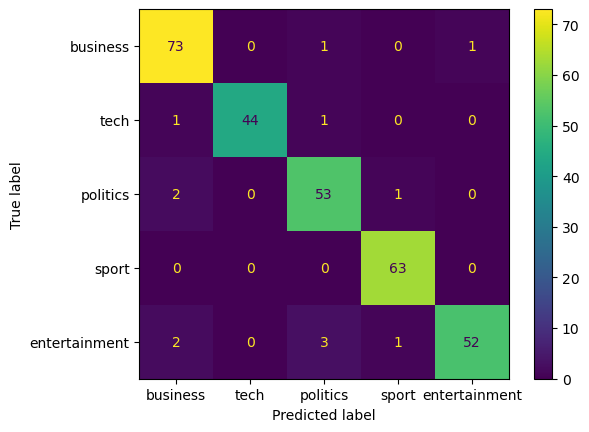

In [16]:
# conufsion matrix 

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=category_names).plot()

In [17]:
# train with new articles 

texts = ['Whats happenign there soomeone died']
prediction = model.predict(texts)
print(prediction)

['entertainment']


In [18]:
# save model 

import joblib

joblib.dump(model,'model.joblib')
print('Success')

Success


In [19]:
# playing with hyperparameters of tfidfvectorizer 

from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=1000),
    MultinomialNB()
)

model.fit(X_train,y_train)
y_pred = model.predict(X_test)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

               precision    recall  f1-score   support

     business       0.96      0.97      0.97        75
entertainment       1.00      0.98      0.99        46
     politics       0.91      0.95      0.93        56
        sport       0.98      1.00      0.99        63
         tech       0.98      0.93      0.96        58

     accuracy                           0.97       298
    macro avg       0.97      0.97      0.97       298
 weighted avg       0.97      0.97      0.97       298



### using params_gried for better search of the best hyperparameters

In [21]:
# if you wanted the custom name then use pipeline instead of make_pipeline
model.named_steps

{'tfidfvectorizer': TfidfVectorizer(max_features=1000, stop_words='english'),
 'multinomialnb': MultinomialNB()}

In [22]:
params_grid = {
    "tfidfvectorizer__max_features": [1000,3000,5000,7000],
    "tfidfvectorizer__ngram_range":[(1,1),(1,2),(1,3)], # combination of unigrams ,bigrams and trigrams (one gram , another gram )
    "tfidfvectorizer__min_df":[1,2,5]
}

In [23]:
from sklearn.model_selection import GridSearchCV

grid = GridSearchCV(model,param_grid=params_grid,cv=10,scoring='accuracy')

grid.fit(X_train,y_train)

print(f"Best params {grid.best_params_}")
print(f"Best estimatort : {grid.best_estimator_}")

Best params {'tfidfvectorizer__max_features': 7000, 'tfidfvectorizer__min_df': 1, 'tfidfvectorizer__ngram_range': (1, 3)}
Best estimatort : Pipeline(steps=[('tfidfvectorizer',
                 TfidfVectorizer(max_features=7000, ngram_range=(1, 3),
                                 stop_words='english')),
                ('multinomialnb', MultinomialNB())])


In [24]:
isinstance(X_test,list)

False

In [25]:
articles = ["The company's quarterly earnings exceeded analysts' expectations after reporting a significant increase in online sales. Executives also announced plans to expand into three new international markets and invest heavily in supply chain automation. Investors responded positively, sending the company's stock price to a new yearly high.",
            "The parliament passed a controversial bill after hours of debate between ruling and opposition lawmakers. Government officials argued that the legislation would improve public administration, while critics claimed it would reduce transparency. The prime minister is expected to address the nation later this week regarding the new policy.",
            "The highly anticipated science fiction movie broke box office records during its opening weekend. Critics praised the performances of the lead actors and the film's visual effects, while audiences applauded its emotional storyline. The production studio has already hinted at a possible sequel.",
            "The home team secured a dramatic victory after scoring the winning goal in the final minutes of the championship match. The coach praised the players for their determination and teamwork, while fans celebrated throughout the night. The victory marks the club's first league title in over a decade.",
            "Researchers unveiled a new artificial intelligence model capable of processing large amounts of data while consuming significantly less computing power. The technology company plans to integrate the system into its cloud services, allowing developers to build faster and more efficient applications."]
preds = model.predict(articles)     
preds                

array(['business', 'politics', 'entertainment', 'sport', 'tech'],
      dtype='<U13')

In [26]:
# politics news fakely classified as tech or business . 

text = ["The chief executive met with government officials to discuss new regulations affecting artificial intelligence companies. While the meeting focused on encouraging innovation, lawmakers also raised concerns about market competition and consumer privacy."]
pred = model.predict(text)
pred

array(['business'], dtype='<U13')

### loading the joblib model 

In [65]:
import joblib 
model = joblib.load("model.joblib")

In [66]:
article = "today one of the greatest accident took place in itahari,Nepal killing over 100 of men and womens . Source says it was caused by the spark produced in the truck that lead to the blasting of 100 of cylinders."

In [67]:
model.predict([article])

array(['sport'], dtype='<U13')

### experimenting with the train test ratio: 


In [30]:
test_sizes = [0.1,0.2,0.3]
for i in test_sizes:
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=i,random_state=42)
    model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    MultinomialNB()
    )
    model.fit(X_train,y_train)
    y_prediction = model.predict(X_test)
    print(f"{i*100}% test-size: accuracy score: {accuracy_score(y_test,y_prediction)}")
    print()
    

10.0% test-size: accuracy score: 0.9798657718120806

20.0% test-size: accuracy score: 0.9731543624161074

30.0% test-size: accuracy score: 0.9753914988814317



### Among different test-sizes the model test-size of 30 % gave more accuracy than remaining ones . 

In [31]:
model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    MultinomialNB()
    )

In [32]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [33]:
from sklearn.model_selection import cross_val_score

### cross val score for calcualting model accuracy and standard deviation . 

In [34]:
cross_val_score(model,X_train,y_train,scoring='accuracy',cv=5).mean()

np.float64(0.9722970359691994)

In [35]:
cross_val_score(model,X_train,y_train,scoring='accuracy',cv=5).std()

np.float64(0.010855372723310336)

### we can also conclude the stablility of the model using the standard devation , since the **std** is low the model is likely to be stable.

### checking model accuracy among different folds.

In [36]:
cross_val_score(model,X_train,y_train,scoring='accuracy',cv=5)

array([0.9832636 , 0.9832636 , 0.97058824, 0.95378151, 0.97058824])

### since the accuracy scores among different folds are found to be similar, so the model is stable among different folds.

---

### comparison table to show accuracy , traiing time , prediction time among the models: 
- Multinomial Naive Bayes, 
- Logistic Regresssion , 
- Support Vector Machine . 

In [37]:
import time 
training_time = []
prediciton_time = []
accuracy_scores =[]

In [38]:
from sklearn.metrics import accuracy_score

model = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    MultinomialNB()
    )
start = time.perf_counter()
model.fit(X_train,y_train)
end = time.perf_counter()

training_time.append(end-start)

start = time.perf_counter()
y_pred = model.predict(X_test)
end = time.perf_counter()
prediciton_time.append(end-start)
accuracy_scores.append(accuracy_score(y_test,y_pred))

In [39]:
print(f"Trainig time: {training_time[-1]:.4f}s")
print(f"Prediction time: {prediciton_time[-1]:.4f}s")
print(f"Accuracy score: {accuracy_scores}")

Trainig time: 1.4830s
Prediction time: 0.1225s
Accuracy score: [0.9731543624161074]


In [40]:
model2 = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    LogisticRegression()
)
start = time.perf_counter()
model2.fit(X_train,y_train)
end = time.perf_counter()

training_time.append(end-start)

start = time.perf_counter()
y_pred = model2.predict(X_test)
end = time.perf_counter()
prediciton_time.append(end-start)
accuracy_scores.append(accuracy_score(y_test,y_pred))

In [41]:
model3 = make_pipeline(
    TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
    LinearSVC()
    )
start = time.perf_counter()
model3.fit(X_train,y_train)
end = time.perf_counter()

training_time.append(end-start)

start = time.perf_counter()
y_pred = model3.predict(X_test)
end = time.perf_counter()
prediciton_time.append(end-start)
accuracy_scores.append(accuracy_score(y_test,y_pred))

In [42]:
accuracy_scores

[0.9731543624161074, 0.9731543624161074, 0.9765100671140939]

In [43]:
pd.DataFrame({
    "training_time":training_time,
    "prediction_time":prediciton_time,
    "accuracy_score":accuracy_scores
},index=["MultinomialNB","LogisticRegression","LinearSVC"])

,training_time,prediction_time,accuracy_score
MultinomialNB,1.482964,0.122527,0.973154
LogisticRegression,1.506278,0.137123,0.973154
LinearSVC,1.456764,0.146667,0.976510


In [44]:
def model_comparison(X,y):
    training_time = []
    prediciton_time = []
    accuracy_scores =[]
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)
    models_list = [MultinomialNB(),LogisticRegression(),LinearSVC()]
    for model in models_list:
        model = make_pipeline(
            TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3)),
            model
        )
        start = time.perf_counter()
        model.fit(X_train,y_train)
        end = time.perf_counter()
        
        training_time.append(end-start)
        
        start = time.perf_counter()
        y_pred = model.predict(X_test)
        end = time.perf_counter()
        
        prediciton_time.append(end-start)
        accuracy_scores.append(accuracy_score(y_test,y_pred))

    return training_time,prediciton_time,accuracy_scores

In [45]:
training_time,prediction_time,accuracy_scores = model_comparison(X,y)

In [46]:
models_list = [MultinomialNB(),LogisticRegression(),LinearSVC()]

pd.DataFrame({
        "training_time(s)":training_time,
        "prediction_time(s)":prediciton_time,
        "accuracy_score":accuracy_scores
        },index=models_list)


,training_time(s),prediction_time(s),accuracy_score
MultinomialNB(),1.403720,0.122527,0.973154
LogisticRegression(),1.565105,0.137123,0.973154
LinearSVC(),1.503995,0.146667,0.976510


### classifying the user input's category and recommending the top 3 best similar news articles based on that category .

In [47]:
user_news = "these days iphone 11 prices have been reduced due to the new coming of the new phones in today's time. It make lead to the degradation of the quality of this phone since the business mind may want people to forcefully adapt to the new generation of the iphone."
predicted_cateogry = model.predict([user_news])[0]

In [48]:
# finding out the news of same cateory from the df 

filtered_df = df[df['Category'] == predicted_cateogry]
filtered_df['Category'].unique()

array(['tech'], dtype=object)

In [49]:
filtered_df['Text'][3]

'lifestyle  governs mobile choice  faster  better or funkier hardware alone is not going to help phone firms sell more handsets  research suggests.  instead  phone firms keen to get more out of their customers should not just be pushing the technology for its own sake. consumers are far more interested in how handsets fit in with their lifestyle than they are in screen size  onboard memory or the chip inside  shows an in-depth study by handset maker ericsson.  historically in the industry there has been too much focus on using technology   said dr michael bjorn  senior advisor on mobile media at ericsson s consumer and enterprise lab.  we have to stop saying that these technologies will change their lives   he said.  we should try to speak to consumers in their own language and help them see how it fits in with what they are doing   he told the bbc news website.  for the study  ericsson interviewed 14 000 mobile phone owners on the ways they use their phone.  people s habits remain the

In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english',max_features=7000,min_df=1,ngram_range=(1,3))

X = tfidf.fit_transform(filtered_df['Text'])


In [51]:
from sklearn.metrics.pairwise import cosine_similarity
query = tfidf.transform([user_news])
similarity = cosine_similarity(query,X)


In [52]:
similarity[0][::-1]

array([0.01522004, 0.0420507 , 0.03019022, 0.02024306, 0.01357166,
       0.00445691, 0.02875641, 0.01533703, 0.06144969, 0.05049322,
       0.03139427, 0.01194212, 0.01402229, 0.01510739, 0.00973457,
       0.03429932, 0.0208473 , 0.00761766, 0.05663321, 0.01841823,
       0.02557693, 0.04526453, 0.03440896, 0.05748201, 0.00816951,
       0.0048611 , 0.00262289, 0.09911131, 0.02944156, 0.02599629,
       0.01863241, 0.01949987, 0.01381876, 0.00275799, 0.01570423,
       0.00140473, 0.01949987, 0.09313244, 0.0092793 , 0.03837095,
       0.00282651, 0.02021614, 0.02603557, 0.03429932, 0.01147369,
       0.01614142, 0.01790111, 0.00929486, 0.04726845, 0.01248158,
       0.03944015, 0.01498845, 0.00477698, 0.05922317, 0.02520445,
       0.06144969, 0.03120025, 0.01929064, 0.00823046, 0.02427729,
       0.05782956, 0.00938752, 0.00823046, 0.0307617 , 0.01960608,
       0.01258683, 0.01213831, 0.02551575, 0.02591493, 0.02139536,
       0.0060284 , 0.06573204, 0.03888402, 0.00458228, 0.01413

In [53]:
indices = np.argsort(similarity[0])[::-1]
indices

array([ 45, 233, 138,  16,  48, 223,   1, 154, 143,  64, 109,  74,   0,
        99, 157,  32, 168, 178, 189,  57,  49, 252, 205, 125, 139,  47,
        43, 144, 207, 150, 200,  56, 237, 242, 106,  73,  15, 115, 251,
        27, 102, 162, 158,  78, 212, 110, 239, 134,  42,  60,  70, 117,
        72,   8, 259,  85,  41, 101,  96,  22, 210,  33,  62, 188, 221,
       149, 155,   7, 100, 238, 245, 217,  17,  97, 175,  39,  13, 250,
       204,  88,  95, 197,  25,  65, 258,   5, 232, 128,  67, 163, 184,
       254,  38,  10,  24, 218,  69, 231,  77, 192,  53, 147, 240, 193,
       206, 201, 173,   9, 120,  26,  59,  83, 176,  30, 160, 174,  84,
       103,  23, 130, 111, 180,   3,  79, 113,   4, 112, 191, 164, 108,
        81,  89, 179,  86, 244, 137, 257, 219, 196,  21, 224, 229, 203,
        46, 116, 131,  29,  35,  76, 230, 241, 214,  90,  18, 124,  61,
       146, 215,  68, 226,  55, 107, 166,  36,  87, 253, 169, 260, 247,
       129,  75, 209,  91,  44, 141,  58,  94, 186, 248, 228, 17

In [54]:
top3 = indices[:3]
recommended = filtered_df.iloc[top3]

In [55]:
print(recommended[['Text','Category']])

                                                   Text Category
279   new consoles promise big problems making games...     tech
1320  finding new homes for old phones re-using old ...     tech
737   camera phones are  must-haves  four times more...     tech


### saving the proper model for the streamlit 


In [62]:
X_train, X_test, y_train, y_test = train_test_split(df['Text'], df['Category'], test_size=0.2, random_state=42)

news_model = make_pipeline(
	TfidfVectorizer(stop_words='english', max_features=7000, min_df=1, ngram_range=(1, 3)),
	MultinomialNB()
)

news_model.fit(X_train, y_train)
y_prediction = news_model.predict(X_test)
print(f"30% test-size: accuracy score: {accuracy_score(y_test, y_prediction)}")

30% test-size: accuracy score: 0.9731543624161074


In [63]:


import joblib

joblib.dump(news_model,'news_model.joblib')
print('Success')

Success
